# Emmons Glacier Steady State
Primary script for Emmons. Here we read in observational data, generate a mesh, set up the model (numerical and param choices), run the model to steady state, and visualize the outputs

In [1]:
import geojson
import geopandas as gpd
import rasterio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import firedrake
from firedrake import Constant, inner, jump, grad, dx, avg, dS, min_value, max_value, conditional, pi
import icepack
from matplotlib.colors import LinearSegmentedColormap
import irksome
from irksome import Dt
import cmcrameri.cm as cmc
from cmcrameri import show_cmaps
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FormatStrFormatter)
import matplotlib.colors as col

## Observational Data

In [2]:
outline_filename = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/emmons_outine/emmons_1896_full.geojson'

m2_h = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/Thickness/m2-thickness_RGI60-02.14297.tif' # Best looking thickness map w/ most logical values
dave_bed = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/surfaces/clipped_bed_dave.tif' 

quinn_velo = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/Velocity/quinn_velo/s2/S2_all_median_horizontal_velocity.tif'
quinn_WinVelo = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/Velocity/quinn_velo/s2/S2_NDJFM_median_horizontal_velocity.tif'
quinn_SumVelo = 'sync/ssa_sia_paper/real_models/wa_glaciers/emmons_glacier/data/Velocity/quinn_velo/s2/S2_MJJAS_median_horizontal_velocity.tif'

In [3]:
with open(outline_filename, "r") as outline_file:
    outline = geojson.load(outline_file)

In [4]:
δ = 0.0

coords = np.array(list(geojson.utils.coords(outline)))
xmin, xmax = coords[:, 0].min() - δ, coords[:, 0].max() + δ
ymin, ymax = coords[:, 1].min() - δ, coords[:, 1].max() + δ

print(f'Outline Bbox: left={xmin}, bottom={ymin}, right={xmax}, top={ymax}')

Outline Bbox: left=594789.305348, bottom=5188812.476617, right=602562.551396, top=5195084.940482


In [5]:
print(f'left={xmin}, bottom={ymin}, right={xmax}, top={ymax}')

left=594789.305348, bottom=5188812.476617, right=602562.551396, top=5195084.940482


In [6]:
# Thickness File (Farinotti)
m2_file = rasterio.open(m2_h, 'r')

h_transform = m2_file.transform

bounds = m2_file.bounds

h_window = rasterio.windows.from_bounds(
    *bounds, 
    transform=h_transform
)

m2_obs = m2_file.read(indexes=1, window = h_window, masked = True)

In [7]:
bed_file = rasterio.open(dave_bed, 'r')

transform = bed_file.transform
window = rasterio.windows.from_bounds(
    left=xmin, bottom=ymin, right=xmax, top=ymax, transform=transform
)

b_obs = bed_file.read(indexes=1, window=window)#, masked = True)
b_obs[b_obs < 0] = 0

In [8]:
b_obs.shape

(627, 777)

In [9]:
def subplots(obs1, transform, window, *args, **kwargs):
    fig, axes = plt.subplots(figsize = (10,8))
    xmin, ymin, xmax, ymax = rasterio.windows.bounds(window, transform)
    extent = (xmin, xmax, ymin, ymax)
    plot = axes.imshow(
        obs1, 
        cmap="Blues", 
        extent=extent
    )
    fig.colorbar(plot,                       
                      orientation = 'vertical', 
                      shrink=0.8, 
                      pad = 0.01, 
                      aspect=50)

    return fig, axes

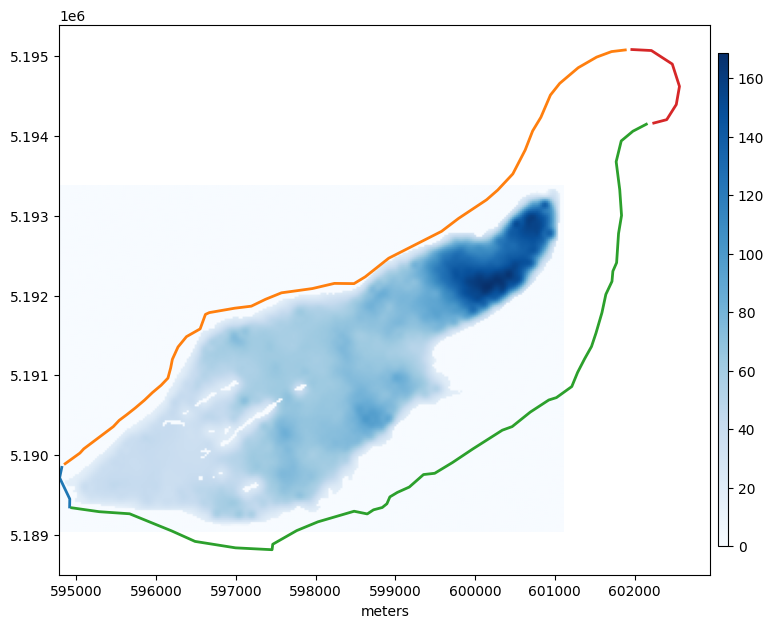

In [10]:
fig, axes = subplots(m2_obs, h_transform, h_window)

for feature in outline["features"]:
    for line_string in feature["geometry"]["coordinates"]:
        xs = np.array(line_string)
        axes.plot(xs[:, 0], xs[:, 1], linewidth=2)

axes.set_xlabel("meters");

In [11]:
b_obs.min()

np.float32(0.0)

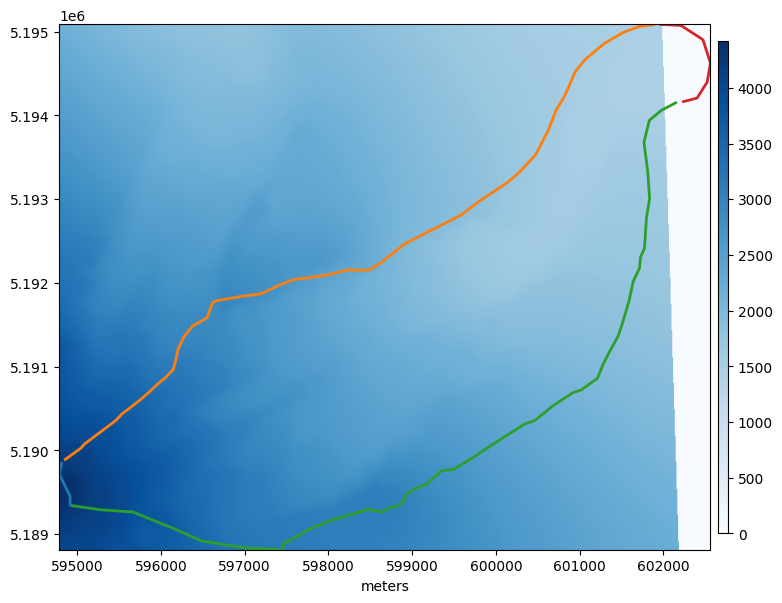

In [12]:
fig, axes = subplots(b_obs, transform, window)

for feature in outline["features"]:
    for line_string in feature["geometry"]["coordinates"]:
        xs = np.array(line_string)
        axes.plot(xs[:, 0], xs[:, 1], linewidth=2)

axes.set_xlabel("meters");

In [13]:
extent = {
    "left": coords[:, 0].min() - 1,
    "right": coords[:, 0].max(),
    "bottom": coords[:, 1].min(),
    "top": coords[:, 1].max(),
}

In [14]:
# Velocity Files
velo_file = rasterio.open(quinn_velo)
window = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file.transform).round_lengths().round_offsets()
transform = velo_file.window_transform(window)
medVelo_obs = velo_file.read(window=window)

velo_file1 = rasterio.open(quinn_WinVelo)
window1 = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file1.transform).round_lengths().round_offsets()
transform1 = velo_file1.window_transform(window1)
WinVelo_obs = velo_file1.read(window=window1)

velo_file2 = rasterio.open(quinn_SumVelo)
window2 = rasterio.windows.from_bounds(**extent, 
                                      transform=velo_file1.transform).round_lengths().round_offsets()
transform2 = velo_file2.window_transform(window2)
SumVelo_obs = velo_file2.read(window=window2)

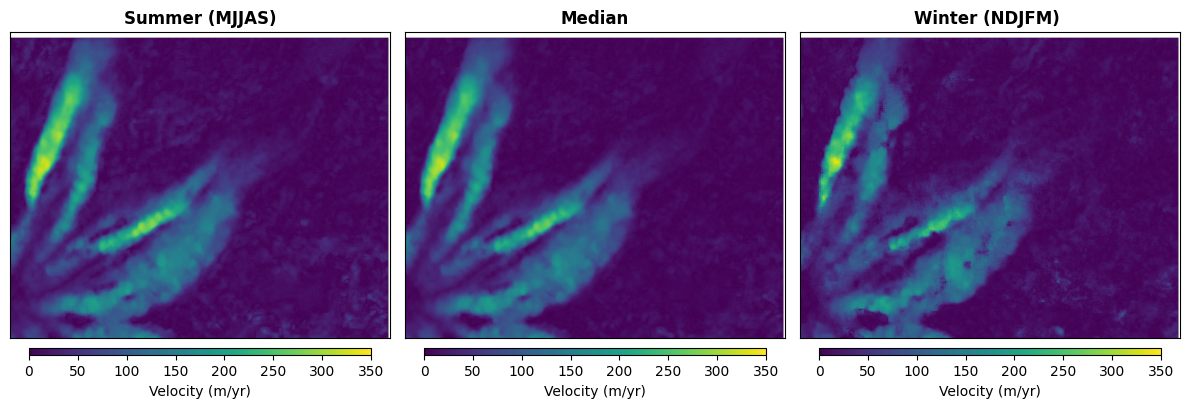

In [15]:
fig, ax = plt.subplots(1, 3, figsize = [12, 10], sharey = True)
colors = ax[0].imshow(SumVelo_obs[0, :, :], 
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      vmax = 350,
                      axes=ax[0])
fig.colorbar(colors, label="Velocity (m/yr)", 
                      orientation = 'horizontal', 
                      shrink=0.9, 
                      pad = 0.01, 
                      aspect=50)
                      #axes = ax[0])
ax[0].set_title('Summer (MJJAS)', fontweight = 'bold')
ax[0].set_aspect("equal")
ax[0].set_xticks([])
ax[0].set_yticks([])

colors1 = ax[1].imshow(medVelo_obs[0, :, :], 
                      vmax = 350,
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      axes=ax[1])
fig.colorbar(colors1, label="Velocity (m/yr)",                           
                      orientation = 'horizontal', 
                      shrink=0.9, 
                      pad = 0.01, 
                      aspect=50)
ax[1].set_title('Median', fontweight = 'bold')
ax[1].set_aspect("equal")
ax[1].set_xticks([])
ax[1].set_yticks([])

colors1 = ax[2].imshow(WinVelo_obs[0, :, :], 
                      vmax = 350,
                      extent=(extent["left"], extent["right"], extent["bottom"], extent["top"]),
                      axes=ax[2])
fig.colorbar(colors1, label="Velocity (m/yr)",                           
                      orientation = 'horizontal', 
                      shrink=0.9, 
                      pad = 0.01, 
                      aspect=50)
ax[2].set_title('Winter (NDJFM) ', fontweight = 'bold')
ax[2].set_aspect("equal")
ax[2].set_xticks([])
ax[2].set_yticks([])

fig.tight_layout()

## Mesh and Function Space Generation

In [16]:
gmsh_mesh = icepack.meshing.collection_to_gmsh(outline)
gmsh_mesh.write("emmons.msh", verbose=False)

mesh = firedrake.Mesh("emmons.msh") # Initial mesh

In [17]:
from firedrake.mg.mesh import MeshHierarchy

mesh0 = firedrake.Mesh('emmons.msh')
hierarchy = MeshHierarchy(mesh0, 3, 1) 
mesh = hierarchy[0] 

In [18]:
cell_sizes = mesh.cell_sizes.dat.data_ro

print(f'Cells: {mesh.num_cells()}')
print(f'Min: {cell_sizes.min()} m')
print(f'Max: {cell_sizes.max()} m')
print(f'Avg: {cell_sizes.mean()} m')

Cells: 1128
Min: 67.35122523951945 m
Max: 731.3741104652709 m
Avg: 218.05080437559553 m


firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


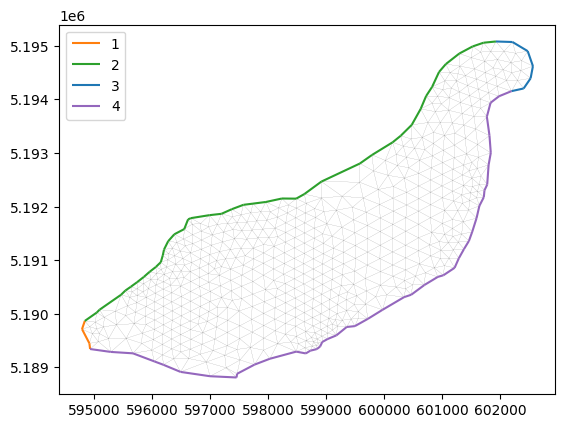

In [19]:
fig, axes = plt.subplots()
kw = {
    "boundary_kw": {"colors": ["tab:orange", "tab:green", "tab:blue", "tab:purple"]},
    "interior_kw": {"linewidth": 0.03},
}
firedrake.triplot(mesh, axes=axes, **kw);
axes.legend(loc="upper left");

In [20]:
## Function Spaces
dg0 = firedrake.FiniteElement("DG", "triangle", 0)
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
cg1 = firedrake.FiniteElement("CG", "triangle", 1)

Q = firedrake.FunctionSpace(mesh, dg1) 
V = firedrake.VectorFunctionSpace(mesh, cg1)

## Projecting onto Mesh

In [21]:
def smoove(q_obs, λ):
    q = q_obs.copy(deepcopy=True)
    J = 0.5 * ((q - q_obs)**2 + Constant(λ)**2 * inner(grad(q), grad(q))) * dx
    F = firedrake.derivative(J, q)
    bc = firedrake.DirichletBC(q.function_space(), q_obs, "on_boundary")
    firedrake.solve(F == 0, q, bc)
    return q

def fix_obs(field):
    ny, nx = field.shape

    x = np.linspace(extent["left"], extent["right"], nx)
    y = np.linspace(extent["bottom"], extent["top"], ny)[::-1]

    return xr.DataArray(
        field,
        dims=("y", "x"),
        coords={"x": x, "y": y},
    )


λ = 250.0

In [22]:
m2 = fix_obs(m2_obs)
h_o = icepack.interpolate(m2, Q)
h0_m2 = firedrake.project(smoove(h_o, λ), Q)

b_d = fix_obs(b_obs)
b_o = icepack.interpolate(b_d, Q)
b0_dave = firedrake.project(smoove(b_o, λ), Q)

v_d = fix_obs(SumVelo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
vs0 = firedrake.project(v_o, Q)

v_d = fix_obs(WinVelo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
vw0 = firedrake.project(v_o, Q)

v_d = fix_obs(medVelo_obs[0, :, :])
v_o = icepack.interpolate(v_d, Q)
vm0 = firedrake.project(v_o, Q)

firedrake:WARNING Subdomain ('on_boundary',) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain ('on_boundary',) is empty. This is likely an error. Did you choose the right label?


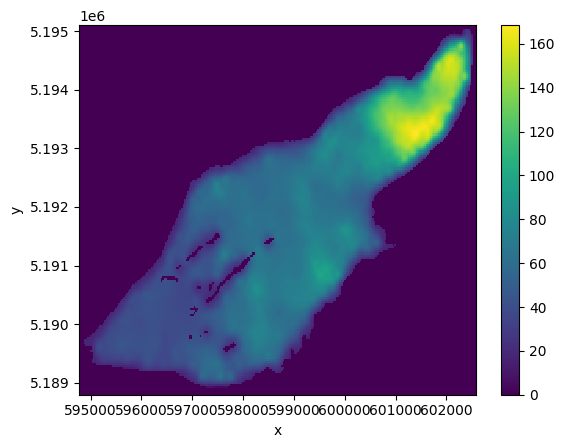

In [23]:
fix_obs(m2_obs).plot(cmap="viridis")
plt.show()

In [24]:
# Calculating the surface from the bed and thickness obs:
s_calc = h0_m2 + b0_dave
s_proj = firedrake.project(s_calc, Q)

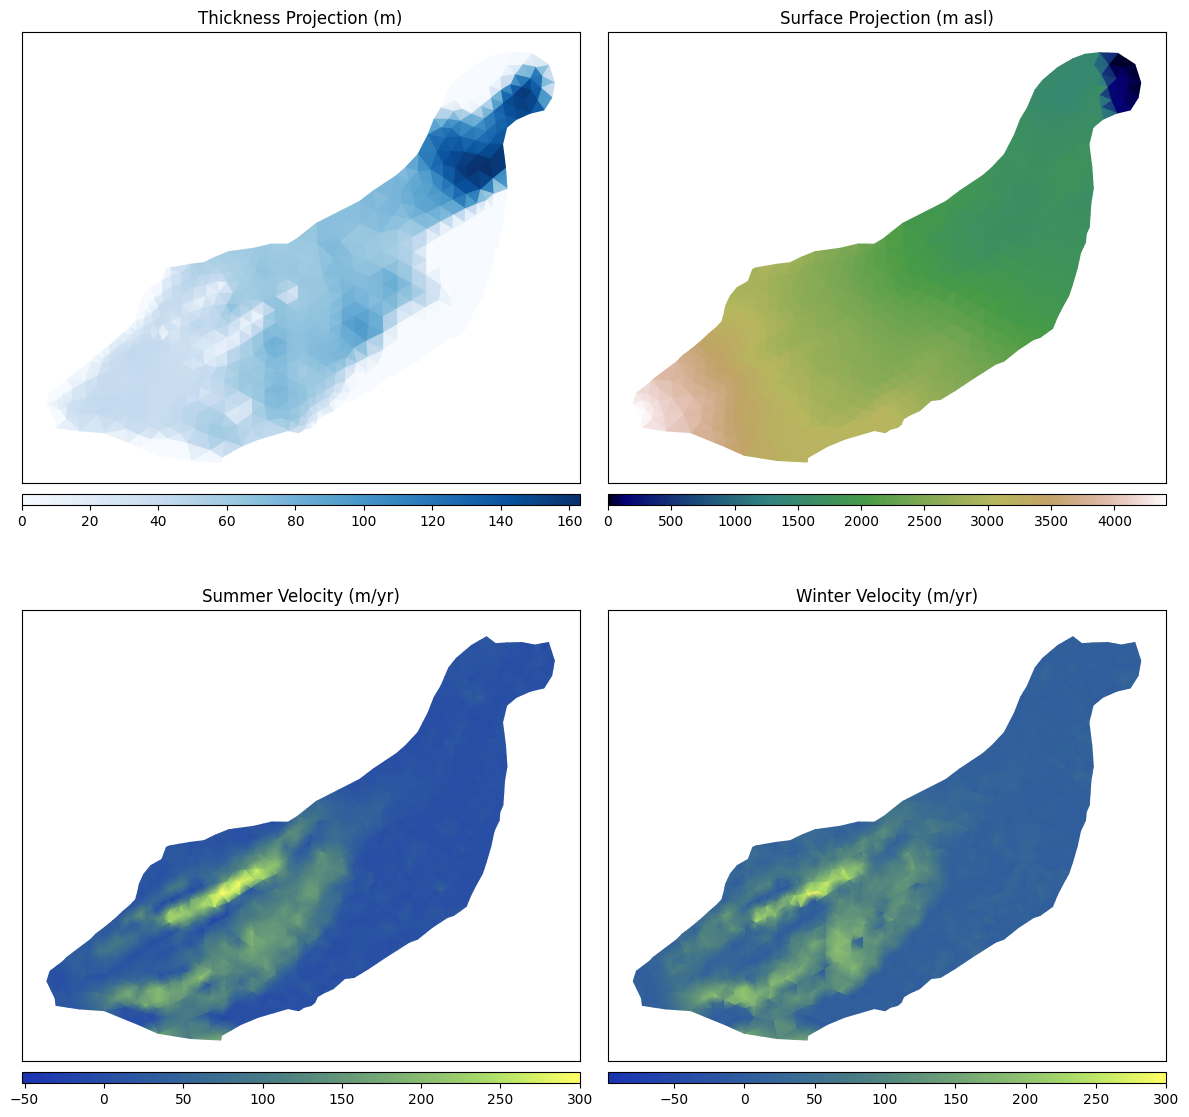

In [25]:
fig, ax = plt.subplots(2, 2, figsize = [12, 12], sharex = True, sharey = True)

colors = firedrake.tripcolor(h0_m2, 
                      cmap = 'Blues',
                      axes=ax[0,0])
fig.colorbar(colors, location = 'bottom', fraction=0.046, pad=0.02,aspect=50)
ax[0,0].set_aspect("equal")
ax[0,0].xaxis.set_minor_locator(AutoMinorLocator())
ax[0,0].tick_params(which='both')
ax[0,0].tick_params(which='major')
ax[0,0].tick_params(which='minor')
ax[0,0].yaxis.set_minor_locator(AutoMinorLocator())

ax[0,0].grid()
ax[0,0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
ax[0,0].set_title('Thickness Projection (m)')

colors = firedrake.tripcolor(s_proj, 
                             vmin = 0,
                             axes=ax[0,1], 
                             cmap = 'gist_earth'
                             )
fig.colorbar(colors, location = 'bottom',fraction=0.046, pad=0.02,aspect=50)

ax[0,1].set_aspect("equal")
ax[0,1].set_title("Surface Projection (m asl)")
colors = firedrake.tripcolor(vs0, 
                             vmax = 300,
                             cmap = cmc.imola,
                             axes=ax[1,0])
ax[0,1].grid()
ax[0,1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.colorbar(colors, location = 'bottom',fraction=0.046, pad=0.02,aspect=50)
ax[1,0].set_aspect("equal")
ax[1,0].set_title("Summer Velocity (m/yr)")

colors = firedrake.tripcolor(vw0, 
                             vmax = 300, 
                             cmap = cmc.imola,
                             axes=ax[1,1])
fig.colorbar(colors, location = 'bottom',fraction=0.046, pad=0.02,aspect=50)
ax[1,1].set_aspect("equal")
ax[1,1].set_title("Winter Velocity (m/yr)")

ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[1,0].set_xticks([])
ax[1,1].set_xticks([])

ax[1,0].set_yticks([])
fig.tight_layout()


## Initial Solves (SIA and Hybrid)
Useful for troubleshooting model initialization issues

In [23]:
from icepack2.constants import gravity, ice_density, glen_flow_law
A = icepack.rate_factor(Constant(279.15)) 

print(f'Enhancement Factor: {icepack.rate_factor(279.15) / icepack.rate_factor(273.15)}') # enhancement factor

h0 = h0_m2
s0 = s_proj


Enhancement Factor: 3.726638696289609


In [24]:
from icepack2.constants import gravity as g, ice_density as ρ_I, glen_flow_law, water_density as ρ_W

# Method for DG0 surface
ρ = Constant(ρ_I)
g = Constant(g)
ρ_W = Constant(ρ_W)

τ_d = firedrake.Function(V)
σ = firedrake.TestFunction(V)
ν = firedrake.FacetNormal(mesh)

F_cells = (inner(τ_d, σ) + ρ*g*h0 * inner(grad(s0), σ)) * dx
F_facets = -inner(avg(ρ*g*h0) * jump(s0, ν), avg(σ)) * dS
F = F_cells + F_facets

firedrake.solve(F == 0, τ_d)

ConvergenceError: Nonlinear solve failed to converge after 0 nonlinear iterations.
Reason:
   DIVERGED_FUNCTION_NANORINF

In [ ]:
n = Constant(glen_flow_law)

u_sia = firedrake.Function(V)
v = firedrake.TestFunction(V)

u_shear = (-2/(n+2)) * h0 * A * (inner(τ_d, τ_d) ** 0.5) ** (n-1) * τ_d
F = inner(u_sia - u_shear, v) * dx

solver_params = {"snes_type": "ksponly", "ksp_type": "gmres"}
fc_params = {"quadrature_degree": 6}
params = {"solver_parameters": solver_params, "form_compiler_parameters": fc_params}
firedrake.solve(F == 0, u_sia, **params)

In [ ]:
u = firedrake.Function(V)

Σ = firedrake.TensorFunctionSpace(mesh, dg0, symmetry=True)
T = firedrake.VectorFunctionSpace(mesh, cg1)
Z = V * Σ * T
z = firedrake.Function(Z)

z.sub(0).assign(u);

In [ ]:
h = h0.copy(deepcopy = True)
s = s0.copy(deepcopy = True)
b = b0_dave.copy(deepcopy = True)

In [ ]:
τ_c = Constant(0.1) # Critical Stress (set to 0.1 mPa)
ε_c = Constant(A * τ_c ** n) # multiply by very small Λ for SIA-like

K = h * A / (n + 2)

t = Constant(0.0)
U_0 = Constant(20.0)
ΔU = Constant(15.0)

U_c = U_0 + ΔU * firedrake.sin(2 * pi * t)# + ϕ) # Critical velocity -> 0 completely turns of long. stress (SIA-like) 100
#U_c = Constant(8.0) 
u_c = K * τ_c ** n + U_c

In [ ]:
glen_rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

α = firedrake.Constant(1e-4)
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
}

u, M, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress": M,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
}

v, N, σ = firedrake.TestFunctions(Z)

In [ ]:
degree = 1
qdegree = max(8, degree ** glen_flow_law)
inflow_ids = [1]
#side_wall_ids = [1, 3]
bc = firedrake.DirichletBC(Z.sub(0), Constant((5.0, 11.0)), inflow_ids)# -----> Inflow set to some velocity prof 5.0, 11.0
pparams = {
    "bcs": bc,
    "form_compiler_parameters": {"quadrature_degree": qdegree},
}

sparams = {
    "solver_parameters": {
        "snes_monitor": None,
        #"snes_linesearch_monitor": None,
        "snes_type": "newtonls",
        "snes_max_it": 200,
        "snes_divergence_tolerance": 1e250,
        "snes_linesearch_type": "secant",
        "snes_linesearch_max_it": 5,
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}

In [ ]:
from icepack2 import model
from icepack2.model.variational import momentum_balance, flow_law, friction_law

H = Constant(100.0)

F = (
    momentum_balance(**fields, test_function=v)
    + firedrake.replace(flow_law(**fields, **glen_rheology, test_function=N), {h: H})
    + α * firedrake.replace(flow_law(**fields, **linear_rheology, test_function=N), {h: H})
    + friction_law(**fields, **glen_rheology, test_function=σ)
    + α * friction_law(**fields, **linear_rheology, test_function=σ)
)

momentum_problem = firedrake.NonlinearVariationalProblem(F, z, **pparams)
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, **sparams)

In [ ]:
num_continuation_steps = 10
for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
    n.assign(exponent)
    momentum_solver.solve()

In [ ]:
u_init, M_init, τ_init = z.subfunctions
u_init.dat.data_ro.max()

In [ ]:
norm = col.Normalize(vmin=0., vmax=250)

fig, axes = plt.subplots(1, 2, figsize = (16, 10), sharex = True, sharey = True)

axes[0].set_aspect("equal")
init_vel = firedrake.tripcolor(vs0, 
                             vmin = 0,
                             vmax = 250, 
                             axes=axes[0])
fig.colorbar(init_vel, fraction=0.046, pad=0.04, orientation = 'horizontal', aspect=50)
axes[0].set_title('Initial Summer Velocity [m/yr]', fontweight = 'bold')
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].tick_params(which='both')
axes[0].tick_params(which='major')
axes[0].tick_params(which='minor')
axes[0].yaxis.set_minor_locator(AutoMinorLocator())

axes[0].grid()
axes[0].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

axes[1].set_aspect("equal")
calc_vel = firedrake.quiver(u_init, 
                             #cmap = cmap2,  
                             norm = norm, 
                             axes=axes[1])

fig.colorbar(calc_vel, fraction=0.046, pad=0.04, orientation = 'horizontal',aspect=50)
axes[1].set_title('Hybrid Velocity with Continuation [m/yr]', fontweight = 'bold')
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].tick_params(which='both')
axes[1].tick_params(which='major')
axes[1].tick_params(which='minor')
axes[1].yaxis.set_minor_locator(AutoMinorLocator())

axes[1].grid()
axes[1].grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

fig.tight_layout()

Working: 
-  fix SMB viz line plot
-  what else can i drop?